# High dimensions

Rare-event estimators tend to degrade as the dimension grows, and it is easy
to mistake a bug for that degradation. This notebook checks the estimator
against a problem with an exact answer at every dimension, from 2 to 200.

The test problem is the tail of a sphere:

$$g(u) = \beta - \lVert u \rVert, \qquad
  P_F = \mathbb{P}(\lVert u \rVert > \beta) = 1 - F_{\chi^2_d}(\beta^2)$$

so the truth is a chi-square tail, known to machine precision for any $d$.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

from safe_ice import SafeICE
from safe_ice.core.safe_ice import DENSITY_FLOOR

plt.rcParams.update({"figure.dpi": 110, "font.size": 10, "figure.facecolor": "white"})


def sphere_problem(beta: float):
    """Failure when the sample leaves a ball of radius beta."""

    def limit_state(u: np.ndarray) -> np.ndarray:
        return beta - np.linalg.norm(u, axis=-1)

    return limit_state

## Why dimension is hard here

The norm of a $d$-dimensional standard normal concentrates near $\sqrt{d}$.
The prior's mass sits on a thin shell, and a proposal initialised in the
wrong place has almost no overlap with it.

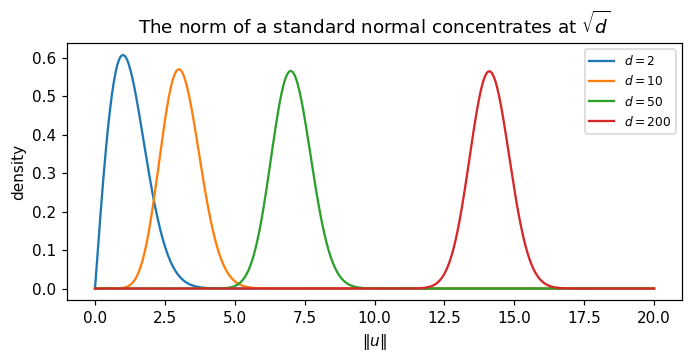

In [2]:
fig, ax = plt.subplots(figsize=(6.4, 3.4))
radii = np.linspace(0, 20, 600)
for d in (2, 10, 50, 200):
    ax.plot(radii, stats.chi.pdf(radii, df=d), label=f"$d={d}$")
ax.set(
    xlabel=r"$\Vert u \Vert$",
    ylabel="density",
    title="The norm of a standard normal concentrates at $\\sqrt{d}$",
)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

This is also where a subtle bug used to live. Probability densities on
$\mathbb{R}^d$ shrink geometrically with dimension, and the proposal density
was once floored at `1e-15` before being divided into the prior. That is not
a small number in high dimensions:

In [3]:
print(f"{'d':>5s} {'median proposal density':>26s} {'below 1e-15?':>14s}")
print("-" * 48)
for d in (2, 10, 20, 30, 50):
    ice = SafeICE(
        limit_state_function=sphere_problem(float(d) ** 0.5 + 2.0),
        dimension=d,
        N=2000,
        random_state=0,
    )
    params = ice._initialize_vmfnm_parameters()
    samples = ice._generate_safe_mixture_samples(params, 0.95)
    densities = ice._evaluate_safe_mixture_density(samples, params, 0.95)
    median = float(np.median(densities))
    print(f"{d:5d} {median:26.3e} {'yes' if median < 1e-15 else 'no':>14s}")

print()
print(f"the floor is now the smallest positive double: {DENSITY_FLOOR:.3e}")

    d    median proposal density   below 1e-15?
------------------------------------------------
    2                  6.856e-02             no


   10                  4.030e-07             no


   20                  1.315e-13             no


   30                  3.386e-20            yes


   50                  3.091e-33            yes

the floor is now the smallest positive double: 2.225e-308


At $d=30$ every sample was being clamped, which inflated the denominator of
the importance weights and collapsed the estimate to about `1e-9` for a true
`1.6e-2`. It presented as a hard ceiling somewhere past $d=20$ and looked
exactly like the weight degeneracy that genuinely afflicts these methods.

## Accuracy against the exact tail

`beta` is chosen for each dimension so the failure probability stays in the
same range, isolating the effect of dimension from the effect of rarity.

In [4]:
CASES = [(2, 3.5), (5, 4.2), (10, 5.0), (20, 6.0), (50, 9.0), (100, 12.0), (200, 16.0)]
SEEDS = range(3)

rows = []
for d, beta in CASES:
    exact = float(stats.chi2.sf(beta**2, df=d))
    estimates = np.array(
        [
            SafeICE(
                limit_state_function=sphere_problem(beta),
                dimension=d,
                N=2000,
                max_iterations=15,
                random_state=s,
            ).run(verbose=False)[0]
            for s in SEEDS
        ]
    )
    rows.append(
        {
            "d": d,
            "beta": beta,
            "exact": exact,
            "estimates": estimates,
            "median": float(np.median(estimates)),
        }
    )

print(
    f"{'d':>5s} {'beta':>6s} {'exact P_F':>12s} {'median':>12s} {'ratio':>7s} {'worst':>7s}"
)
print("-" * 56)
for r in rows:
    ratios = r["estimates"] / r["exact"]
    worst = ratios[np.argmax(np.abs(np.log(ratios)))]
    print(
        f"{r['d']:5d} {r['beta']:6.1f} {r['exact']:12.3e} {r['median']:12.3e} "
        f"{r['median'] / r['exact']:6.2f}x {worst:6.2f}x"
    )

    d   beta    exact P_F       median   ratio   worst
--------------------------------------------------------
    2    3.5    2.187e-03    2.173e-03   0.99x   1.02x
    5    4.2    3.433e-03    3.409e-03   0.99x   0.99x
   10    5.0    5.346e-03    5.330e-03   1.00x   1.03x
   20    6.0    1.538e-02    1.523e-02   0.99x   1.02x
   50    9.0    3.610e-03    3.591e-03   0.99x   0.99x
  100   12.0    2.629e-03    2.641e-03   1.00x   1.08x
  200   16.0    4.565e-03    4.591e-03   1.01x   0.98x


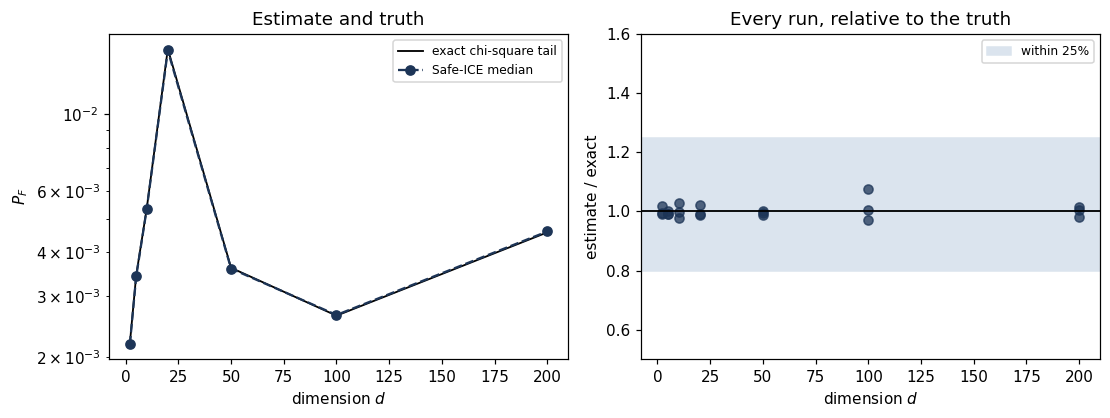

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10.2, 3.9))

dims = [r["d"] for r in rows]
axes[0].plot(
    dims, [r["exact"] for r in rows], "k-", lw=1.2, label="exact chi-square tail"
)
axes[0].plot(
    dims, [r["median"] for r in rows], "o--", color="#1d3557", label="Safe-ICE median"
)
axes[0].set(
    xlabel="dimension $d$", ylabel="$P_F$", yscale="log", title="Estimate and truth"
)
axes[0].legend(fontsize=8)

for r in rows:
    axes[1].plot(
        [r["d"]] * len(r["estimates"]),
        r["estimates"] / r["exact"],
        "o",
        color="#1d3557",
        ms=6,
        alpha=0.75,
    )
axes[1].axhline(1.0, color="black", lw=1.2)
axes[1].axhspan(0.8, 1.25, color="#dbe4ee", zorder=0, label="within 25%")
axes[1].set(
    xlabel="dimension $d$",
    ylabel="estimate / exact",
    title="Every run, relative to the truth",
)
axes[1].set_ylim(0.5, 1.6)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

The ratio stays flat from $d=2$ to $d=200$. There is no dimensional ceiling —
what looked like one was a fixed constant in the wrong place.

## What the mixture does as dimension grows

The sphere problem is radially symmetric and has a single failure mode, so
the automatic component selection should prune the mixture back towards one
component regardless of where it started.

In [6]:
print(f"{'d':>5s} {'K0':>5s} {'final K':>9s} {'iterations':>12s}")
print("-" * 34)
for d, beta in CASES:
    ice = SafeICE(
        limit_state_function=sphere_problem(beta),
        dimension=d,
        N=2000,
        max_iterations=15,
        random_state=0,
    )
    _pf, results = ice.run(verbose=False)
    print(
        f"{d:5d} {ice.K0:5d} {results['final_components']:9d} "
        f"{len(results['iterations']):12d}"
    )

    d    K0   final K   iterations
----------------------------------


    2    20         7            2


    5    20        11            2


   10    20         6            2


   20    20         1            2


   50    20         1            2


  100    20         1            2


  200    20         1            2


From $d=20$ upward it settles on a single component, having started with
twenty and without being told that the problem has one mode. At lower
dimensions it keeps a handful — several components can share one mode, and
the penalty prunes what is redundant rather than driving to a minimum. That
is what the cross-entropy term in the EM step is for.